Common complexes: 165
AlphaFold3 Both Oracle: High=124/165=75.2%, Medium=151/165=91.5%, Acceptable=155/165=93.9%
AlphaFold3 Both Model: High=101/165=61.2%, Medium=141/165=85.5%, Acceptable=147/165=89.1%
AlphaFold3 MSA Oracle: High=126/165=76.4%, Medium=151/165=91.5%, Acceptable=153/165=92.7%
AlphaFold3 MSA Model: High=105/165=63.6%, Medium=141/165=85.5%, Acceptable=150/165=90.9%
AlphaFold3 Template Oracle: High=95/165=57.6%, Medium=130/165=78.8%, Acceptable=141/165=85.5%
AlphaFold3 Template Model: High=76/165=46.1%, Medium=113/165=68.5%, Acceptable=132/165=80.0%
AlphaFold3 None Oracle: High=24/165=14.5%, Medium=36/165=21.8%, Acceptable=68/165=41.2%
AlphaFold3 None Model: High=21/165=12.7%, Medium=32/165=19.4%, Acceptable=49/165=29.7%
Protenix Both Oracle: High=118/165=71.5%, Medium=144/165=87.3%, Acceptable=157/165=95.2%
Protenix Both Model: High=104/165=63.0%, Medium=133/165=80.6%, Acceptable=148/165=89.7%
Protenix MSA Oracle: High=120/165=72.7%, Medium=147/165=89.1%, Acceptable=155/1

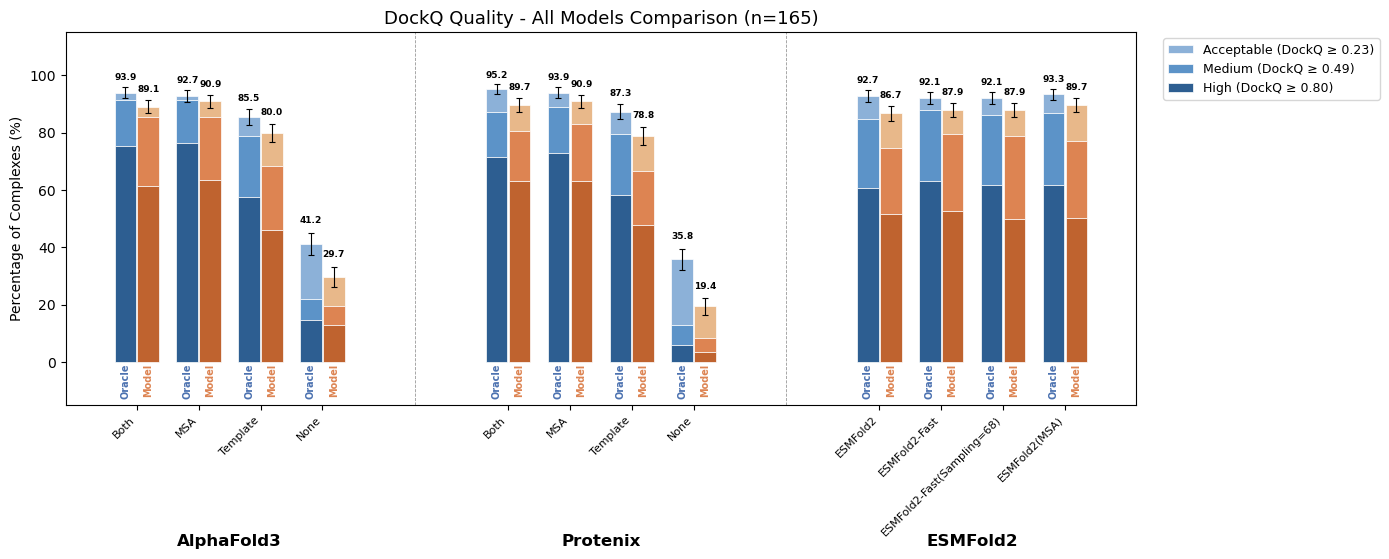

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DockQ 累计堆叠柱状图
# Oracle: 每个 complex 选 dockq_score 最大的样本
# Model:  每个 complex 中选 iptm 最大的样本

PROCESSED_DIR = "src/processed"
plt.rcParams['svg.fonttype'] = 'none'
def get_label(method_raw):
    return _DISPLAY.get(method_raw, method_raw)

_DISPLAY = {
    # af3 / ptx
    "msa_template": "Both",
    "msa_notemplate": "MSA",
    "nomsa_template": "Template",
    "nomsa_notemplate": "None",
    # esmfold2
    "nomsa_loop10_samples200": "ESMFold2",
    "fast_loop10_samples200": "ESMFold2-Fast",
    "fast_loop10_samplingsteps68": "ESMFold2-Fast(Sampling=68)",
    "msa_nonpairing_loop10_samples200": "ESMFold2(MSA)",
}

# X-tick order within each model group follows get_label's dict order
_label_rank = {lbl: i for i, (raw, lbl) in enumerate(_DISPLAY.items())}

# ====== 可调参数 ======
model_order = ["af3", "ptx", "esmfold2"]
model_display = {
    "af3": "AlphaFold3",
    "ptx": "Protenix",
    "esmfold2": "ESMFold2",
}
bar_gap = 0.02        # Oracle 与 Model 两根柱子之间的空白间隙
bar_width = 0.35       # 每根柱子的宽度
method_spacing = 2.0   # 同一模型内方法之间的间隔
# =====================

processed_files = sorted([f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")])

data_map = {}
item_order = []
for fname in processed_files:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, fname), dtype={"complex": str})
    model = df["model"].iloc[0]
    method_raw = df["method"].iloc[0]
    label = get_label(method_raw)
    data_map[(model, label)] = df
    if (model, label) not in item_order:
        item_order.append((model, label))

common = set(next(iter(data_map.values()))["complex"].unique())
for df in data_map.values():
    common &= set(df["complex"].unique())
common_complexes = sorted(common)
print(f"Common complexes: {len(common_complexes)}")

all_items = []
model_midpoints = {}
x_positions = []
sep_positions = []

pos = 0
for idx, model_name in enumerate(model_order):
    items = [it for it in item_order if it[0] == model_name]
    # Sort within each model group by get_label's dict order
    items = sorted(items, key=lambda it: _label_rank.get(it[1], 999))
    n = len(items)
    centers = []
    for i, item in enumerate(items):
        centers.append(pos + i)
        x_positions.append(pos + i)
        all_items.append(item)
    model_midpoints[model_name] = (centers[0] + centers[-1]) / 2 if n > 1 else float(centers[0])
    pos += n + method_spacing
    if idx < len(model_order) - 1:
        sep_positions.append((centers[-1] + pos) / 2)

x = np.array(x_positions)
all_labels = [lbl for (_, lbl) in all_items]

rows = []
for model, label in all_items:
    df = data_map[(model, label)]
    df = df[df["complex"].isin(common_complexes)]
    total = df["complex"].nunique()
    for mode, mode_label in [("oracle", "Oracle"), ("model", "Model")]:
        high = medium = low = 0
        for _, group in df.groupby("complex"):
            best_dockq = group["dockq_score"].max() if mode == "oracle" else group.loc[group["iptm"].idxmax(), "dockq_score"]
            if best_dockq >= 0.80:
                high += 1
            if best_dockq >= 0.49:
                medium += 1
            if best_dockq >= 0.23:
                low += 1
        rows.append({
            "item": (model, label),
            "mode": mode_label,
            "high": high / total * 100,
            "medium": medium / total * 100,
            "acceptable": low / total * 100,
            "acceptable_err": np.sqrt((low / total) * (1 - low / total) / total) * 100,
        })
        print(f"{model_display.get(model, model.upper())} {label} {mode_label}: "
              f"High={high}/{total}={high/total*100:.1f}%, "
              f"Medium={medium}/{total}={medium/total*100:.1f}%, "
              f"Acceptable={low}/{total}={low/total*100:.1f}%")

df_plot = pd.DataFrame(rows)

oracle_colors = {"high": "#2D5E91", "medium": "#5C93C8", "acceptable": "#8CB1D8"}
model_colors  = {"high": "#BF632F", "medium": "#DD8452", "acceptable": "#E8B88A"}
legend_labels = {
    "acceptable": "Acceptable (DockQ ≥ 0.23)",
    "medium": "Medium (DockQ ≥ 0.49)",
    "high": "High (DockQ ≥ 0.80)",
}

fig, ax = plt.subplots(figsize=(14, 6))

for sep in sep_positions:
    ax.axvline(sep, color="#999999", linewidth=0.6, linestyle="--", zorder=0)

# Oracle 左偏，Model 右偏，bar_gap 直接控制两者之间的空白
bar_offset = bar_width / 2 + bar_gap / 2

for mode_offset, mode_name in enumerate(["Oracle", "Model"]):
    offset = -bar_offset if mode_name == "Oracle" else bar_offset
    sub = df_plot[df_plot["mode"] == mode_name]
    colors = oracle_colors if mode_name == "Oracle" else model_colors
    val_map = {r["item"]: r for _, r in sub.iterrows()}
    high_vals = np.array([val_map[item]["high"] for item in all_items])
    med_vals = np.array([val_map[item]["medium"] - val_map[item]["high"] for item in all_items])
    pass_vals = np.array([val_map[item]["acceptable"] - val_map[item]["medium"] for item in all_items])
    total_pass = high_vals + med_vals + pass_vals
    err_vals = np.array([val_map[item]["acceptable_err"] for item in all_items])
    ax.bar(x + offset, pass_vals, bar_width, bottom=high_vals + med_vals,
           label=legend_labels["acceptable"] if mode_offset == 0 else "",
           color=colors["acceptable"], edgecolor="white", linewidth=0.5)
    ax.bar(x + offset, med_vals, bar_width, bottom=high_vals,
           label=legend_labels["medium"] if mode_offset == 0 else "",
           color=colors["medium"], edgecolor="white", linewidth=0.5)
    ax.bar(x + offset, high_vals, bar_width, bottom=0,
           label=legend_labels["high"] if mode_offset == 0 else "",
           color=colors["high"], edgecolor="white", linewidth=0.5)
    ax.errorbar(x + offset, total_pass, yerr=err_vals,
                fmt="none", ecolor="black", capsize=2, capthick=0.8, elinewidth=0.8)
    for i in range(len(x_positions)):
        ax.text(x[i] + offset, -0.5, mode_name,
                ha="center", va="top", fontsize=7, fontweight="bold",
                color="#4C72B0" if mode_name == "Oracle" else "#DD8452", rotation=90)
    for i in range(len(x_positions)):
        err = err_vals[i]
        label_y = total_pass[i] + max(err * 1.5 + 0.8, 1.5)
        ax.text(x[i] + offset, label_y,
                f"{total_pass[i]:.1f}", ha="center", va="bottom",
                fontsize=6.5, fontweight="bold")

for model_name in model_order:
    mid = model_midpoints[model_name]
    ax.text(mid, -60, model_display[model_name], ha="center", va="top",
            fontsize=12, fontweight="bold")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)

ax.set_ylabel("Percentage of Complexes (%)")
ax.set_title(f"DockQ Quality - All Models Comparison (n={len(common_complexes)})", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylim(-15, 115)

plt.tight_layout()
os.makedirs("summary", exist_ok=True)
plt.savefig("summary/dockq.svg", bbox_inches="tight")
plt.show()